# Minimal model of energy metabolism

Nathaniel Linden (UCSD MAE) - Feb  2023

In [1]:
import sunode
import pymc as pm
import matplotlib.pyplot as plt
import numpy as np
import sympy as sym
from sympy import init_printing
init_printing()

import sys
sys.path.insert(0, '../odes')
import metabolism as model1
from get_left_nullspace_vecs_invariants import get_left_nullspace_vecs_invariants as left_ns
%matplotlib inline

WARNING (aesara.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


### Run with the following ATP fluxes:
- Basal ATP flux = 25.7 mM/s; kGly = 1521.0
- Stressed ATP flux = 10.3 mM/s; kGly = 609.5

In [2]:
# load the necessary dictionaries
params = model1.metab_get_params()
states = model1.metab_get_states()
nparams = len(params)
nstates = len(states)

# create sunode problem
problem = sunode.SympyProblem(
    params=params,
    states=states,
    rhs_sympy=model1.metab_RHS,
    # specify variables to take gradients wrt
    derivative_params=(),
)

# set up solver
solver = sunode.solver.Solver(problem, solver='BDF')
lib = sunode._cvodes.lib
lib.CVodeSetMaxNumSteps(solver._ode, 5000)

# Initial conditions
y0 = np.zeros((), dtype=problem.state_dtype)
# free adenine nucleotides
y0['AMP'] = 2e-5   # 'AMP' mM
y0['ADP'] = 1.3e-1 # 'ADP mM
y0['ATP'] = 8.2   # 'ATP mM

 # evaluate the solution at these times
tvals = np.linspace(0, 7, 500)

 # set the parameters
 # TODO: MORE RESEARCH ON THE PARAMETERS!
solver.set_params_dict({
    'kGly': 1521.0, #25.7,
    'kHydro':1.4e-3,
    # 'VforAK':14.66,
    # 'kmm':0.35,
    # 'kmd':0.32,
    # 'kmt':0.27,
    # 'KeqAK':2.21,
    'kForAK':40.44,
    'kRevAK':1.1e-3,
    'VmaxOxPhos':0.5 , # mM/s from Coccimiglio,
    'Kadp': 5.8e-2, # mM from Coccimiglio,
    'n': 2.568, # unitless from Coccimiglio,
})


yout = solver.make_output_buffers(tvals)
solver.solve(t0=0, tvals=tvals, y0=y0, y_out=yout)

# set the parameters
 # TODO: MORE RESEARCH ON THE PARAMETERS!
solver.set_params_dict({
    'kGly': 609.5, #10.3,
    'kHydro':1.4e-3,
    # 'VforAK':14.66,
    # 'kmm':0.35,
    # 'kmd':0.32,
    # 'kmt':0.27,
    # 'KeqAK':2.21,
    'kForAK':40.44,
    'kRevAK':1.1e-3,
    'VmaxOxPhos':0.5 , # mM/s from Coccimiglio,
    'Kadp': 5.8e-2, # mM from Coccimiglio,
    'n': 2.568, # unitless from Coccimiglio,
})

y0_new = np.zeros((), dtype=problem.state_dtype)
y0_new['AMP'] = yout.view(problem.state_dtype)['AMP'][-1]   # 'AMP' mM
y0_new['ADP'] = yout.view(problem.state_dtype)['ADP'][-1] # 'ADP mM
y0_new['ATP'] = yout.view(problem.state_dtype)['ATP'][-1]  # 'ATP mM

yout1 = solver.make_output_buffers(tvals)
solver.solve(t0=0, tvals=tvals, y0=y0_new, y_out=yout1)

Normalized change in AMP:ATP [1.45728695]


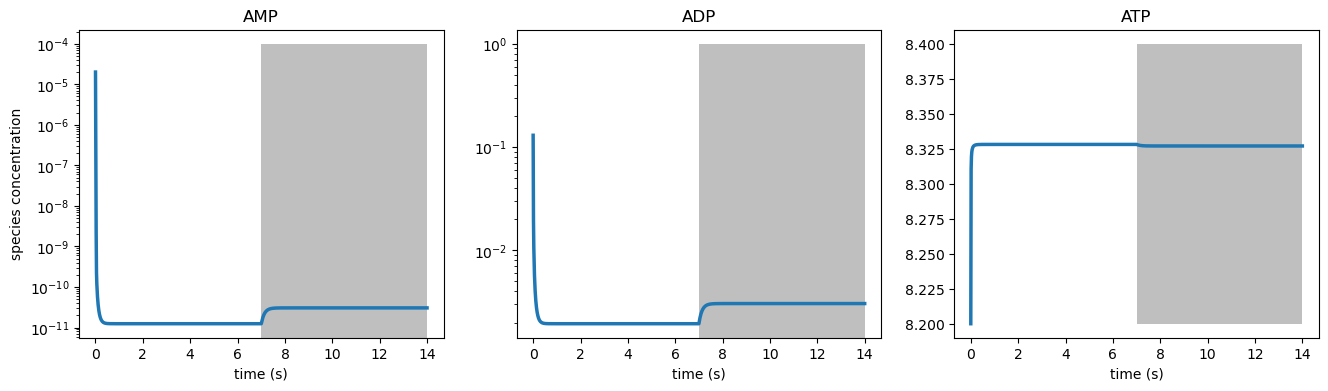

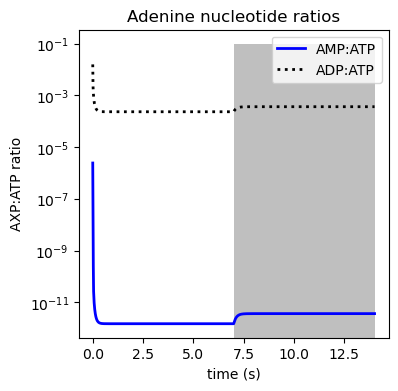

In [3]:
# Metabolism plots
fig0, ax0 = plt.subplots(1,3, figsize=(16,4))
# AMP
# plot [AMP] with thicker line
ax0[0].plot(np.hstack((tvals, tvals[-1]+tvals)), 
            np.vstack((yout.view(problem.state_dtype)['AMP'], yout1.view(problem.state_dtype)['AMP'])), linewidth=2.5)
ax0[0].fill_between(np.arange(7, 15), 0.0, 1e-4, color='grey', alpha=0.5, lw=0)
# formatting
ax0[0].set_yscale('log')
ax0[0].set_ylabel('species concentration')
ax0[0].set_xlabel('time (s)')
ax0[0].set_title('AMP')
# ADP
# plot [ADP] with thicker line
ax0[1].plot(np.hstack((tvals, tvals[-1]+tvals)), 
            np.vstack((yout.view(problem.state_dtype)['ADP'], yout1.view(problem.state_dtype)['ADP'])), linewidth=2.5)
ax0[1].fill_between(np.arange(7, 15), 0.0, 1.0, color='grey', alpha=0.5, lw=0)
# formatting
ax0[1].set_yscale('log')
ax0[1].set_xlabel('time (s)')
ax0[1].set_title('ADP')
# ATP
# plot [ATP] with thicker line
ax0[2].plot(np.hstack((tvals, tvals[-1]+tvals)), 
            np.vstack((yout.view(problem.state_dtype)['ATP'], yout1.view(problem.state_dtype)['ATP'])), linewidth=2.5)
ax0[2].fill_between(np.arange(7, 15), 8.2, 8.4, color='grey', alpha=0.5, lw=0)
# formatting
# ax0[2].set_yscale('log')
ax0[2].set_xlabel('time (s)')
ax0[2].set_title('ATP')

fig1, ax1 = plt.subplots(1,1, figsize=(4,4))
AMP_ATP_ratio0 = yout.view(problem.state_dtype)['AMP'] / yout.view(problem.state_dtype)['ATP']
ADP_ATP_ratio0 = yout.view(problem.state_dtype)['ADP'] / yout.view(problem.state_dtype)['ATP']
AMP_ATP_ratio1 = yout1.view(problem.state_dtype)['AMP'] / yout1.view(problem.state_dtype)['ATP']
ADP_ATP_ratio1 = yout1.view(problem.state_dtype)['ADP'] / yout1.view(problem.state_dtype)['ATP']
ax1.plot(np.hstack((tvals, tvals[-1]+tvals)), np.vstack((AMP_ATP_ratio0, AMP_ATP_ratio1)), 'b', linewidth=2)
ax1.plot(np.hstack((tvals, tvals[-1]+tvals)), np.vstack((ADP_ATP_ratio0, ADP_ATP_ratio1)), 'k:', linewidth=2)
ax1.fill_between(np.arange(7, 15), 0.0, 0.1, color='grey', alpha=0.5, lw=0)
ax1.set_yscale('log')
ax1.set_ylabel('AXP:ATP ratio')
ax1.set_xlabel('time (s)')
ax1.legend(('AMP:ATP', 'ADP:ATP'))
ax1.set_title('Adenine nucleotide ratios')

print('Normalized change in AMP:ATP', ((yout1.view(problem.state_dtype)['AMP'][-1] / yout1.view(problem.state_dtype)['ATP'][-1]) 
      - (yout.view(problem.state_dtype)['AMP'][-1] / yout.view(problem.state_dtype)['ATP'][-1])) / (yout.view(problem.state_dtype)['AMP'][-1] / yout.view(problem.state_dtype)['ATP'][-1]))

### Run with the following ATP fluxes:
- Basal ATP flux = 25.7 mM/s; kGly = 1521.0
- Stressed ATP flux = 1.03 mM/s; kGly = 60.95

In [64]:
# load the necessary dictionaries
params = model1.metab_get_params()
states = model1.metab_get_states()
nparams = len(params)
nstates = len(states)

# create sunode problem
problem = sunode.SympyProblem(
    params=params,
    states=states,
    rhs_sympy=model1.metab_RHS,
    # specify variables to take gradients wrt
    derivative_params=(),
)

# set up solver
solver = sunode.solver.Solver(problem, solver='BDF')
lib = sunode._cvodes.lib
lib.CVodeSetMaxNumSteps(solver._ode, 5000)

# Initial conditions
y0 = np.zeros((), dtype=problem.state_dtype)
# free adenine nucleotides
y0['AMP'] = 2e-5   # 'AMP' mM
y0['ADP'] = 1.3e-1 # 'ADP mM
y0['ATP'] = 8.2   # 'ATP mM

 # evaluate the solution at these times
tvals = np.linspace(0, 7, 500)

 # set the parameters
 # TODO: MORE RESEARCH ON THE PARAMETERS!
solver.set_params_dict({
    'kGly': 1521.0, #25.7,
    'kHydro':1.4e-3,
    # 'VforAK':14.66,
    # 'kmm':0.35,
    # 'kmd':0.32,
    # 'kmt':0.27,
    # 'KeqAK':2.21,
    'kForAK':40.44,
    'kRevAK':1.1e-3,
    'VmaxOxPhos':0.5 , # mM/s from Coccimiglio,
    'Kadp': 5.8e-2, # mM from Coccimiglio,
    'n': 2.568, # unitless from Coccimiglio,
})


yout = solver.make_output_buffers(tvals)
solver.solve(t0=0, tvals=tvals, y0=y0, y_out=yout)

# set the parameters
 # TODO: MORE RESEARCH ON THE PARAMETERS!
solver.set_params_dict({
    'kGly': 60.95, #10.3,
    'kHydro':1.4e-3,
    # 'VforAK':14.66,
    # 'kmm':0.35,
    # 'kmd':0.32,
    # 'kmt':0.27,
    # 'KeqAK':2.21,
    'kForAK':40.44,
    'kRevAK':1.1e-3,
    'VmaxOxPhos':0.5 , # mM/s from Coccimiglio,
    'Kadp': 5.8e-2, # mM from Coccimiglio,
    'n': 2.568, # unitless from Coccimiglio,
})

y0_new = np.zeros((), dtype=problem.state_dtype)
y0_new['AMP'] = yout.view(problem.state_dtype)['AMP'][-1]   # 'AMP' mM
y0_new['ADP'] = yout.view(problem.state_dtype)['ADP'][-1] # 'ADP mM
y0_new['ATP'] = yout.view(problem.state_dtype)['ATP'][-1]  # 'ATP mM

yout1 = solver.make_output_buffers(tvals)
solver.solve(t0=0, tvals=tvals, y0=y0_new, y_out=yout1)

Normalized change in AMP:ATP [16.96055945]


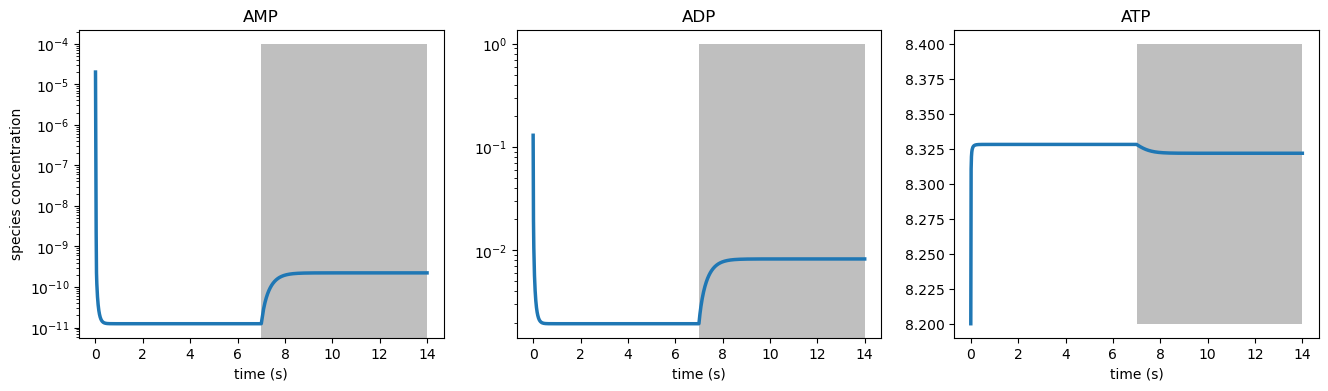

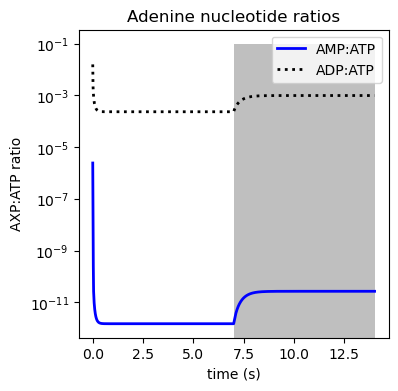

In [65]:
# Metabolism plots
fig0, ax0 = plt.subplots(1,3, figsize=(16,4))
# AMP
# plot [AMP] with thicker line
ax0[0].plot(np.hstack((tvals, tvals[-1]+tvals)), 
            np.vstack((yout.view(problem.state_dtype)['AMP'], yout1.view(problem.state_dtype)['AMP'])), linewidth=2.5)
ax0[0].fill_between(np.arange(7, 15), 0.0, 1e-4, color='grey', alpha=0.5, lw=0)
# formatting
ax0[0].set_yscale('log')
ax0[0].set_ylabel('species concentration')
ax0[0].set_xlabel('time (s)')
ax0[0].set_title('AMP')
# ADP
# plot [ADP] with thicker line
ax0[1].plot(np.hstack((tvals, tvals[-1]+tvals)), 
            np.vstack((yout.view(problem.state_dtype)['ADP'], yout1.view(problem.state_dtype)['ADP'])), linewidth=2.5)
ax0[1].fill_between(np.arange(7, 15), 0.0, 1.0, color='grey', alpha=0.5, lw=0)
# formatting
ax0[1].set_yscale('log')
ax0[1].set_xlabel('time (s)')
ax0[1].set_title('ADP')
# ATP
# plot [ATP] with thicker line
ax0[2].plot(np.hstack((tvals, tvals[-1]+tvals)), 
            np.vstack((yout.view(problem.state_dtype)['ATP'], yout1.view(problem.state_dtype)['ATP'])), linewidth=2.5)
ax0[2].fill_between(np.arange(7, 15), 8.2, 8.4, color='grey', alpha=0.5, lw=0)
# formatting
# ax0[2].set_yscale('log')
ax0[2].set_xlabel('time (s)')
ax0[2].set_title('ATP')

fig1, ax1 = plt.subplots(1,1, figsize=(4,4))
AMP_ATP_ratio0 = yout.view(problem.state_dtype)['AMP'] / yout.view(problem.state_dtype)['ATP']
ADP_ATP_ratio0 = yout.view(problem.state_dtype)['ADP'] / yout.view(problem.state_dtype)['ATP']
AMP_ATP_ratio1 = yout1.view(problem.state_dtype)['AMP'] / yout1.view(problem.state_dtype)['ATP']
ADP_ATP_ratio1 = yout1.view(problem.state_dtype)['ADP'] / yout1.view(problem.state_dtype)['ATP']
ax1.plot(np.hstack((tvals, tvals[-1]+tvals)), np.vstack((AMP_ATP_ratio0, AMP_ATP_ratio1)), 'b', linewidth=2)
ax1.plot(np.hstack((tvals, tvals[-1]+tvals)), np.vstack((ADP_ATP_ratio0, ADP_ATP_ratio1)), 'k:', linewidth=2)
ax1.fill_between(np.arange(7, 15), 0.0, 0.1, color='grey', alpha=0.5, lw=0)
ax1.set_yscale('log')
ax1.set_ylabel('AXP:ATP ratio')
ax1.set_xlabel('time (s)')
ax1.legend(('AMP:ATP', 'ADP:ATP'))
ax1.set_title('Adenine nucleotide ratios')

print('Normalized change in AMP:ATP', ((yout1.view(problem.state_dtype)['AMP'][-1] / yout1.view(problem.state_dtype)['ATP'][-1]) 
      - (yout.view(problem.state_dtype)['AMP'][-1] / yout.view(problem.state_dtype)['ATP'][-1])) / (yout.view(problem.state_dtype)['AMP'][-1] / yout.view(problem.state_dtype)['ATP'][-1]))

### Run with the following ATP fluxes:
- Basal ATP flux = 25.7 mM/s; kGly = 1521.0
- Stressed ATP flux = 0.103 mM/s; kGly = 6.095

In [20]:
# load the necessary dictionaries
params = model1.metab_get_params()
states = model1.metab_get_states()
nparams = len(params)
nstates = len(states)

# create sunode problem
problem = sunode.SympyProblem(
    params=params,
    states=states,
    rhs_sympy=model1.metab_RHS,
    # specify variables to take gradients wrt
    derivative_params=(),
)

# set up solver
solver = sunode.solver.Solver(problem, solver='BDF')
lib = sunode._cvodes.lib
lib.CVodeSetMaxNumSteps(solver._ode, 5000)

# Initial conditions
y0 = np.zeros((), dtype=problem.state_dtype)
# free adenine nucleotides
y0['AMP'] = 2e-3   # 'AMP' mM
y0['ADP'] = 1.3e-1 # 'ADP mM
y0['ATP'] = 8.2   # 'ATP mM

 # evaluate the solution at these times
tvals = np.linspace(0, 7, 500)

 # set the parameters
 # TODO: MORE RESEARCH ON THE PARAMETERS!
solver.set_params_dict({
    'kGly': 4500.0, #25.7,
    'kHydro':1.4e-3,
    # 'VforAK':14.66,
    # 'kmm':0.35,
    # 'kmd':0.32,
    # 'kmt':0.27,
    # 'KeqAK':2.21,
    'kForAK':4.044e-1,
    'kRevAK':1.1e0,
    'VmaxOxPhos':0.5 , # mM/s from Coccimiglio,
    'Kadp': 5.8e-2, # mM from Coccimiglio,
    'n': 2.568, # unitless from Coccimiglio,
})


yout = solver.make_output_buffers(tvals)
solver.solve(t0=0, tvals=tvals, y0=y0, y_out=yout)

# set the parameters
 # TODO: MORE RESEARCH ON THE PARAMETERS!
solver.set_params_dict({
    'kGly': 4.5, #10.3,
    'kHydro':1.4e-3,
    'kForAK':4.044e-1,
    'kRevAK':1.1e0,
    'VmaxOxPhos':0.5 , # mM/s from Coccimiglio,
    'Kadp': 5.8e-2, # mM from Coccimiglio,
    'n': 2.568, # unitless from Coccimiglio,
})

y0_new = np.zeros((), dtype=problem.state_dtype)
y0_new['AMP'] = yout.view(problem.state_dtype)['AMP'][-1]   # 'AMP' mM
y0_new['ADP'] = yout.view(problem.state_dtype)['ADP'][-1] # 'ADP mM
y0_new['ATP'] = yout.view(problem.state_dtype)['ATP'][-1]  # 'ATP mM

yout1 = solver.make_output_buffers(tvals)
solver.solve(t0=0, tvals=tvals, y0=y0_new, y_out=yout1)

Normalized change in AMP:ATP [126.53235725]


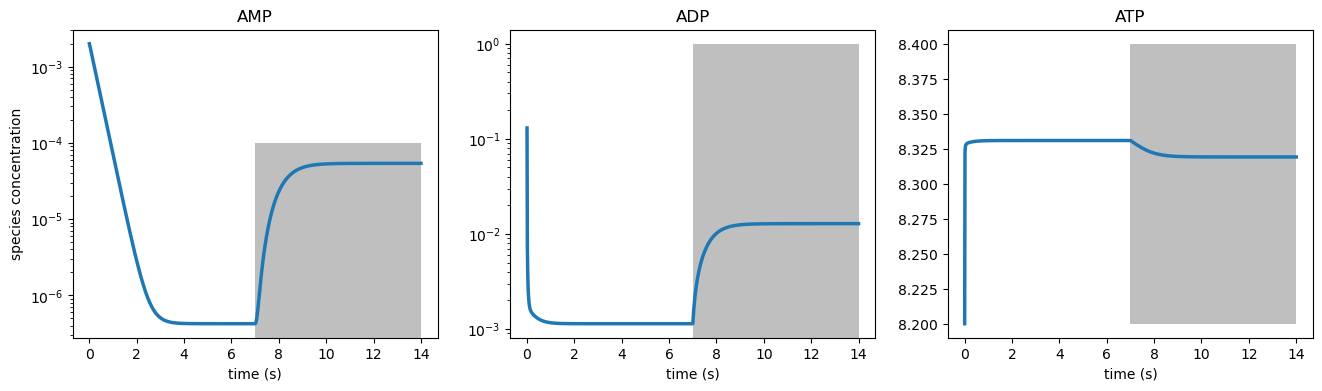

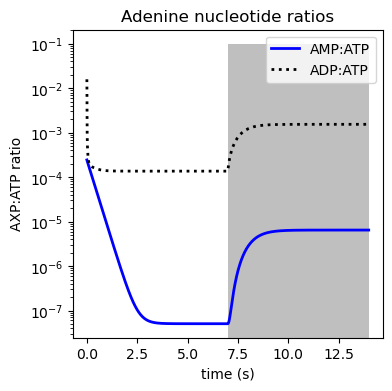

In [21]:
# Metabolism plots
fig0, ax0 = plt.subplots(1,3, figsize=(16,4))
# AMP
# plot [AMP] with thicker line
ax0[0].plot(np.hstack((tvals, tvals[-1]+tvals)), 
            np.vstack((yout.view(problem.state_dtype)['AMP'], yout1.view(problem.state_dtype)['AMP'])), linewidth=2.5)
ax0[0].fill_between(np.arange(7, 15), 0.0, 1e-4, color='grey', alpha=0.5, lw=0)
# formatting
ax0[0].set_yscale('log')
ax0[0].set_ylabel('species concentration')
ax0[0].set_xlabel('time (s)')
ax0[0].set_title('AMP')
# ADP
# plot [ADP] with thicker line
ax0[1].plot(np.hstack((tvals, tvals[-1]+tvals)), 
            np.vstack((yout.view(problem.state_dtype)['ADP'], yout1.view(problem.state_dtype)['ADP'])), linewidth=2.5)
ax0[1].fill_between(np.arange(7, 15), 0.0, 1.0, color='grey', alpha=0.5, lw=0)
# formatting
ax0[1].set_yscale('log')
ax0[1].set_xlabel('time (s)')
ax0[1].set_title('ADP')
# ATP
# plot [ATP] with thicker line
ax0[2].plot(np.hstack((tvals, tvals[-1]+tvals)), 
            np.vstack((yout.view(problem.state_dtype)['ATP'], yout1.view(problem.state_dtype)['ATP'])), linewidth=2.5)
ax0[2].fill_between(np.arange(7, 15), 8.2, 8.4, color='grey', alpha=0.5, lw=0)
# formatting
# ax0[2].set_yscale('log')
ax0[2].set_xlabel('time (s)')
ax0[2].set_title('ATP')

fig1, ax1 = plt.subplots(1,1, figsize=(4,4))
AMP_ATP_ratio0 = yout.view(problem.state_dtype)['AMP'] / yout.view(problem.state_dtype)['ATP']
ADP_ATP_ratio0 = yout.view(problem.state_dtype)['ADP'] / yout.view(problem.state_dtype)['ATP']
AMP_ATP_ratio1 = yout1.view(problem.state_dtype)['AMP'] / yout1.view(problem.state_dtype)['ATP']
ADP_ATP_ratio1 = yout1.view(problem.state_dtype)['ADP'] / yout1.view(problem.state_dtype)['ATP']
ax1.plot(np.hstack((tvals, tvals[-1]+tvals)), np.vstack((AMP_ATP_ratio0, AMP_ATP_ratio1)), 'b', linewidth=2)
ax1.plot(np.hstack((tvals, tvals[-1]+tvals)), np.vstack((ADP_ATP_ratio0, ADP_ATP_ratio1)), 'k:', linewidth=2)
ax1.fill_between(np.arange(7, 15), 0.0, 0.1, color='grey', alpha=0.5, lw=0)
ax1.set_yscale('log')
ax1.set_ylabel('AXP:ATP ratio')
ax1.set_xlabel('time (s)')
ax1.legend(('AMP:ATP', 'ADP:ATP'))
ax1.set_title('Adenine nucleotide ratios')

print('Normalized change in AMP:ATP', ((yout1.view(problem.state_dtype)['AMP'][-1] / yout1.view(problem.state_dtype)['ATP'][-1]) 
      - (yout.view(problem.state_dtype)['AMP'][-1] / yout.view(problem.state_dtype)['ATP'][-1])) / (yout.view(problem.state_dtype)['AMP'][-1] / yout.view(problem.state_dtype)['ATP'][-1]))